In [18]:
import pandas as pd
df = pd.read_csv("accidents_weather_ca_merged.csv")
df.head()


,Start_Lat,Start_Lng,Start_Time,Severity,lat,lon,weather_main,weather_desc,temp_f,humidity,visibility,wind_speed,rain_1h
0,38.362831,-122.267197,2016-12-09 05:25:36,2,38.362831,-122.267197,Clear,clear sky,60.03,77,10000,6.91,0
1,34.022625,-118.156616,2016-07-12 10:55:04,2,34.022625,-118.156616,Clear,clear sky,65.93,40,10000,4.61,0
2,38.254620,-122.335907,2016-06-06 11:20:16,2,38.254620,-122.335907,Clear,clear sky,60.04,76,10000,6.91,0
3,38.003071,-121.337051,2016-12-17 09:25:08,2,38.003071,-121.337051,Clear,clear sky,58.32,78,10000,9.22,0
4,37.403236,-122.046913,2016-11-04 11:01:44,2,37.403236,-122.046913,Clear,clear sky,60.51,72,10000,8.05,0


In [19]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Start_Lat     500 non-null    float64
 1   Start_Lng     500 non-null    float64
 2   Start_Time    500 non-null    object 
 3   Severity      500 non-null    int64  
 4   lat           500 non-null    float64
 5   lon           500 non-null    float64
 6   weather_main  500 non-null    object 
 7   weather_desc  500 non-null    object 
 8   temp_f        500 non-null    float64
 9   humidity      500 non-null    int64  
 10  visibility    500 non-null    int64  
 11  wind_speed    500 non-null    float64
 12  rain_1h       500 non-null    int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 50.9+ KB


,Start_Lat,Start_Lng,Severity,lat,lon,temp_f,humidity,visibility,wind_speed,rain_1h
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0,500.000000,500.0
mean,37.412993,-121.308837,2.386000,37.412993,-121.308837,59.491980,69.910000,10000.0,7.452720,0.0
std,1.479164,1.426249,0.491413,1.479164,1.426249,3.069826,12.764473,0.0,3.573148,0.0
min,32.725410,-123.426376,2.000000,32.725410,-123.426376,39.990000,25.000000,10000.0,0.000000,0.0
25%,37.353806,-122.120951,2.000000,37.353806,-122.120951,58.205000,70.000000,10000.0,4.610000,0.0
50%,37.778513,-121.778049,2.000000,37.778513,-121.778049,59.380000,73.000000,10000.0,8.050000,0.0
75%,38.410708,-121.327802,3.000000,38.410708,-121.327802,60.370000,77.000000,10000.0,9.220000,0.0
max,39.526264,-116.871635,4.000000,39.526264,-116.871635,67.750000,87.000000,10000.0,18.410000,0.0


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load merged dataset
df = pd.read_csv("accidents_weather_ca_merged.csv")

# Quick sanity checks
df.head(), df.shape


(   Start_Lat   Start_Lng           Start_Time  Severity        lat  \
 0  38.362831 -122.267197  2016-12-09 05:25:36         2  38.362831   
 1  34.022625 -118.156616  2016-07-12 10:55:04         2  34.022625   
 2  38.254620 -122.335907  2016-06-06 11:20:16         2  38.254620   
 3  38.003071 -121.337051  2016-12-17 09:25:08         2  38.003071   
 4  37.403236 -122.046913  2016-11-04 11:01:44         2  37.403236   
 
           lon weather_main weather_desc  temp_f  humidity  visibility  \
 0 -122.267197        Clear    clear sky   60.03        77       10000   
 1 -118.156616        Clear    clear sky   65.93        40       10000   
 2 -122.335907        Clear    clear sky   60.04        76       10000   
 3 -121.337051        Clear    clear sky   58.32        78       10000   
 4 -122.046913        Clear    clear sky   60.51        72       10000   
 
    wind_speed  rain_1h  
 0        6.91        0  
 1        4.61        0  
 2        6.91        0  
 3        9.22        

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global style settings
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "axes.edgecolor": "black",
    "grid.alpha": 0.3
})

NAVY = "#0B3C5D"



PLOT 1 — Distribution of Accident Severity in California

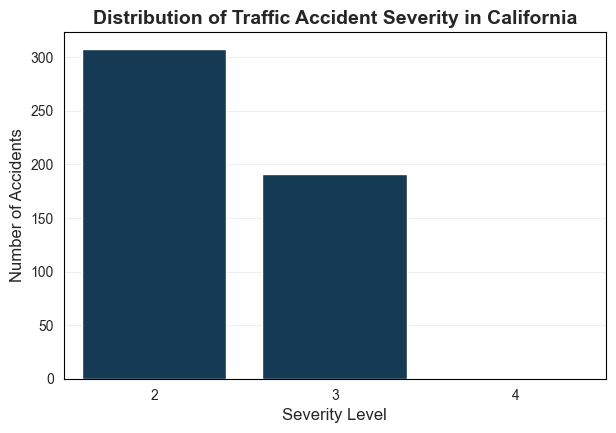

In [22]:
sns.countplot(x="Severity", data=df, color=NAVY)
plt.title("Distribution of Traffic Accident Severity in California")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")
plt.show()



severity_counts = (
    df["Severity"]
    .value_counts()
    .sort_index()
    .reset_index()
)

severity_counts.columns = ["Severity", "Count"]

severity_counts.to_json("severity_distribution.json", orient="records")


Accidents by Weather Condition

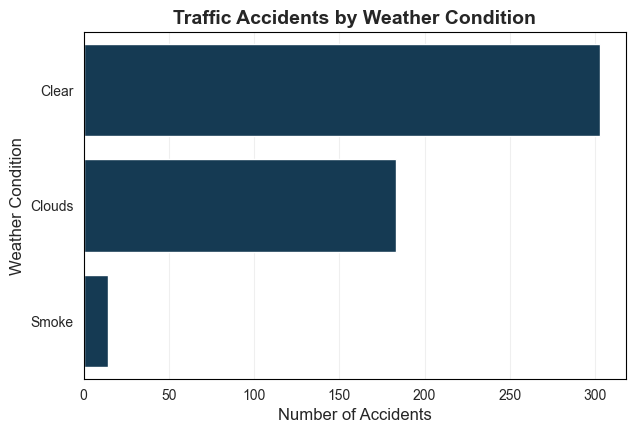

In [23]:
top_weather = df["weather_main"].value_counts().nlargest(6).index
sns.countplot(
    y="weather_main",
    data=df[df["weather_main"].isin(top_weather)],
    color=NAVY
)
plt.title("Traffic Accidents by Weather Condition")
plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")
plt.show()



weather_counts = (
    df["weather_main"]
    .value_counts()
    .nlargest(6)
    .reset_index()
)

weather_counts.columns = ["Weather", "Count"]

weather_counts.to_json("weather_distribution.json", orient="records")


Visibility Distribution During Accidents

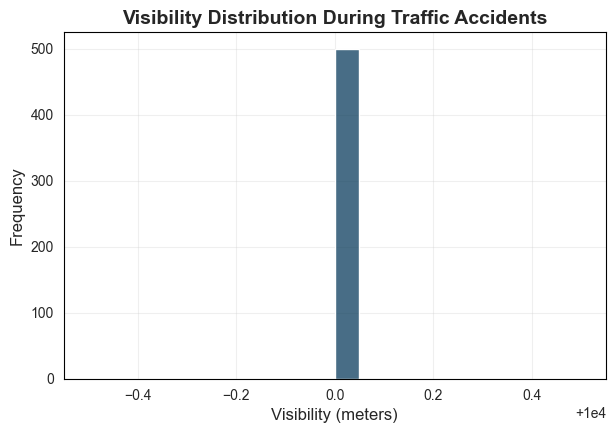

In [24]:
sns.histplot(df["visibility"], bins=20, color=NAVY)
plt.title("Visibility Distribution During Traffic Accidents")
plt.xlabel("Visibility (meters)")
plt.ylabel("Frequency")
plt.show()


df[["visibility"]].to_json("visibility_distribution.json", orient="records")


Accident Severity vs VisibilityAccident Severity vs Visibility

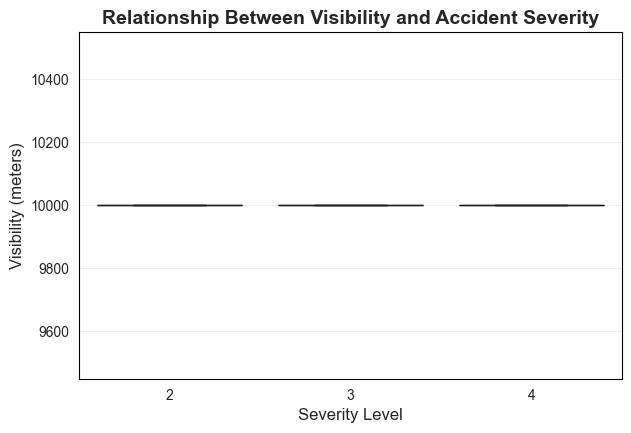

In [25]:
sns.boxplot(x="Severity", y="visibility", data=df, color=NAVY)
plt.title("Relationship Between Visibility and Accident Severity")
plt.xlabel("Severity Level")
plt.ylabel("Visibility (meters)")
plt.show()


visibility_severity = df[["Severity", "visibility"]]

visibility_severity.to_json("visibility_severity.json", orient="records")


Temperature Distribution During Accidents

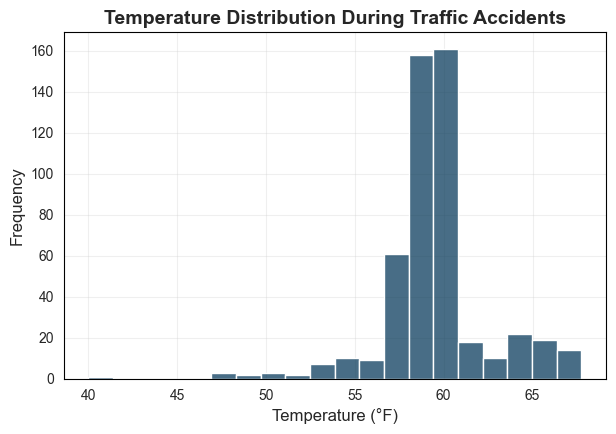

In [26]:
sns.histplot(df["temp_f"], bins=20, color=NAVY)
plt.title("Temperature Distribution During Traffic Accidents")
plt.xlabel("Temperature (°F)")
plt.ylabel("Frequency")
plt.show()


df[["temp_f"]].to_json("temperature_distribution.json", orient="records")

Accident Severity vs Temperature

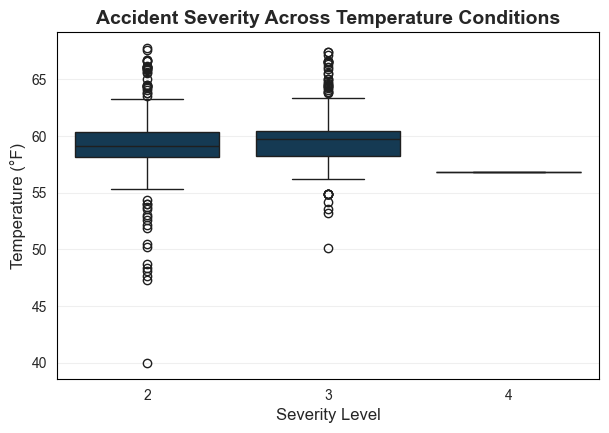

In [27]:
sns.boxplot(x="Severity", y="temp_f", data=df, color=NAVY)
plt.title("Accident Severity Across Temperature Conditions")
plt.xlabel("Severity Level")
plt.ylabel("Temperature (°F)")
plt.show()


temp_severity = df[["Severity", "temp_f"]]

temp_severity.to_json("temperature_severity.json", orient="records")


Wind Speed Distribution During Accidents

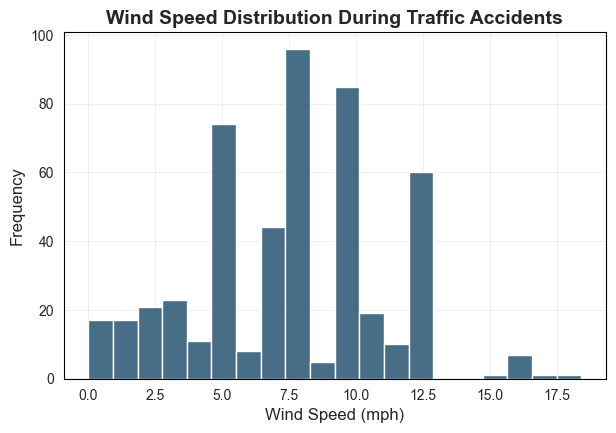

In [28]:
sns.histplot(df["wind_speed"], bins=20, color=NAVY)
plt.title("Wind Speed Distribution During Traffic Accidents")
plt.xlabel("Wind Speed (mph)")
plt.ylabel("Frequency")
plt.show()



df[["wind_speed"]].to_json("wind_distribution.json", orient="records") 

Accident Severity vs Wind Speed

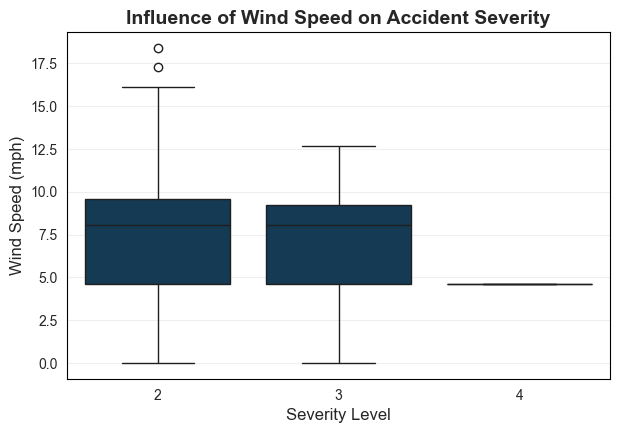

In [29]:
sns.boxplot(x="Severity", y="wind_speed", data=df, color=NAVY)
plt.title("Influence of Wind Speed on Accident Severity")
plt.xlabel("Severity Level")
plt.ylabel("Wind Speed (mph)")
plt.show()



wind_severity = df[["Severity", "wind_speed"]]

wind_severity.to_json("wind_severity.json", orient="records")

Accidents by Time of Day

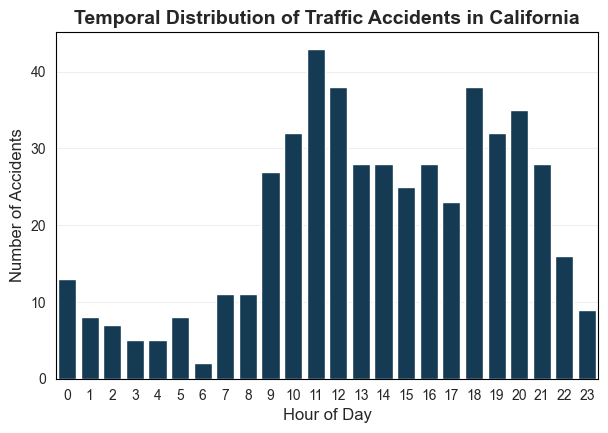

In [30]:
df["Hour"] = pd.to_datetime(df["Start_Time"]).dt.hour

sns.countplot(x="Hour", data=df, color=NAVY)
plt.title("Temporal Distribution of Traffic Accidents in California")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()



hour_counts = (
    df["Hour"]
    .value_counts()
    .sort_index()
    .reset_index()
)

hour_counts.columns = ["Hour", "Count"]

hour_counts.to_json("hourly_distribution.json", orient="records")


Correlation Analysis of Weather Variables and Severity

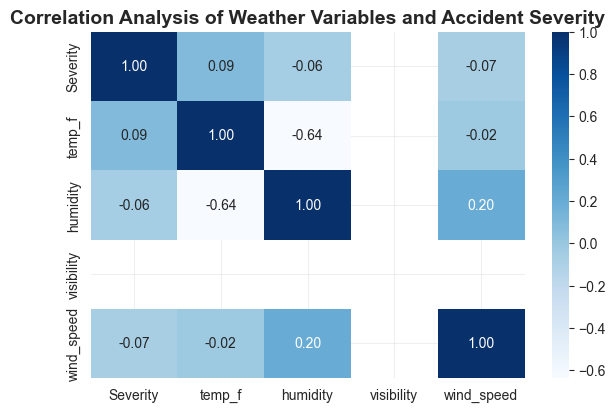

In [31]:
numeric_cols = ["Severity", "temp_f", "humidity", "visibility", "wind_speed"]
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Analysis of Weather Variables and Accident Severity")
plt.show()



corr.reset_index().to_json("correlation_matrix.json", orient="records")
